# Assignment 03 - Field EDA

This notebook analyzes New Mexico field-level crop and soil datasets (2008-2020).

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"

soil_path = DATA_DIR / "soil" / "nm_soil_data.csv"
crop_path = DATA_DIR / "crops" / "nm_cdl_2008_2020.csv"
fields_path = DATA_DIR / "boundaries" / "nm_top_200_fields.geojson"

soil_path, crop_path, fields_path
FIGURES_DIR = PROJECT_ROOT / "notebooks" / "03_field_eda" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures directory: {FIGURES_DIR}")

Project root: /workspaces/EVTLR-Project
Figures directory: /workspaces/EVTLR-Project/notebooks/03_field_eda/figures


In [3]:
soil_df = pd.read_csv(soil_path)
crop_df = pd.read_csv(crop_path)

with open(fields_path, "r", encoding="utf-8") as f:
    fields_geojson = json.load(f)

fields_records = [feature.get("properties", {}) for feature in fields_geojson.get("features", [])]
fields_df = pd.DataFrame(fields_records)

print(f"soil_df shape: {soil_df.shape}")
print(f"crop_df shape: {crop_df.shape}")
print(f"fields_df shape: {fields_df.shape}")

soil_df shape: (3945, 16)
crop_df shape: (2587, 6)
fields_df shape: (199, 4)


In [4]:
def inspect_dataframe(df: pd.DataFrame, name: str) -> None:
    print("=" * 100)
    print(f"{name} - .info()")
    print("=" * 100)
    df.info()
    print()

    print("=" * 100)
    print(f"{name} - .describe(include='all').T")
    print("=" * 100)
    display(df.describe(include="all").T)

inspect_dataframe(soil_df, "Soil data (horizon-level)")
inspect_dataframe(crop_df, "Crop data (field-year)")
inspect_dataframe(fields_df, "Field boundaries properties")

Soil data (horizon-level) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 3945 entries, 0 to 3944
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mukey         3945 non-null   int64  
 1   muname        3945 non-null   str    
 2   compname      3945 non-null   str    
 3   comppct_r     3945 non-null   int64  
 4   drainagecl    3938 non-null   str    
 5   hzdept_r      3908 non-null   float64
 6   hzdepb_r      3908 non-null   float64
 7   om_r          3714 non-null   float64
 8   ph1to1h2o_r   3775 non-null   float64
 9   awc_r         3777 non-null   float64
 10  claytotal_r   3775 non-null   float64
 11  sandtotal_r   3350 non-null   float64
 12  silttotal_r   3350 non-null   float64
 13  dbthirdbar_r  3717 non-null   float64
 14  cec7_r        3775 non-null   float64
 15  field_id      3945 non-null   str    
dtypes: float64(10), int64(2), str(4)
memory usage: 778.0 KB

Soil data (horizon-level) - .des

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
mukey,3945.0,NaN,NaN,NaN,825860.190368,684771.5043,376394.0,376434.0,376474.0,1547772.0,2606831.0
muname,3945,135,"Kimbrough-Lea complex, dry, 0 to 3 percent slopes",385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
compname,3945,102,Kimbrough,309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
comppct_r,3945.0,NaN,NaN,NaN,24.788847,29.83215,1.0,5.0,7.0,45.0,100.0
drainagecl,3938,5,Well drained,3675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hzdept_r,3908.0,NaN,NaN,NaN,8.221085,9.942695,0.0,0.0,0.0,17.0,29.0
hzdepb_r,3908.0,NaN,NaN,NaN,42.625896,35.32959,3.0,20.0,30.0,54.25,203.0
om_r,3714.0,NaN,NaN,NaN,1.062593,0.846795,0.05,0.5,0.75,1.4,3.9
ph1to1h2o_r,3775.0,NaN,NaN,NaN,7.670861,0.440328,6.5,7.3,7.7,8.0,8.9
awc_r,3777.0,NaN,NaN,NaN,0.126402,0.033994,0.0,0.12,0.13,0.15,0.2


Crop data (field-year) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   field_id      2587 non-null   str    
 1   year          2587 non-null   int64  
 2   crop_code     2587 non-null   int64  
 3   crop_name     2587 non-null   str    
 4   dominant_pct  2587 non-null   float64
 5   total_pixels  2587 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 185.4 KB

Crop data (field-year) - .describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,2587,199,NM_FIELD_001,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2587.0,NaN,NaN,NaN,2014.0,3.742381,2008.0,2011.0,2014.0,2017.0,2020.0
crop_code,2587.0,NaN,NaN,NaN,144.117124,50.325889,1.0,152.0,152.0,176.0,236.0
crop_name,2587,17,Grassland/Pasture,1144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dominant_pct,2587.0,NaN,NaN,NaN,87.279552,18.864028,19.8,81.55,97.5,100.0,100.0
total_pixels,2587.0,NaN,NaN,NaN,259.899497,186.482395,21.0,106.0,212.0,367.0,856.0


Field boundaries properties - .info()
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   field_id     199 non-null    str    
 1   county       199 non-null    str    
 2   county_fips  199 non-null    str    
 3   area_acres   199 non-null    float64
dtypes: float64(1), str(3)
memory usage: 10.3 KB

Field boundaries properties - .describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,199,199,NM_FIELD_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county,199,3,Lea,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county_fips,199,3,025,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_acres,199.0,NaN,NaN,NaN,560.595969,403.777943,38.334832,229.378072,454.751185,776.451273,1856.477282


In [5]:
soil_numeric_cols = [
    "comppct_r",
    "hzdept_r",
    "hzdepb_r",
    "om_r",
    "ph1to1h2o_r",
    "awc_r",
    "claytotal_r",
    "sandtotal_r",
    "silttotal_r",
    "dbthirdbar_r",
    "cec7_r",
]

for col in soil_numeric_cols:
    soil_df[col] = pd.to_numeric(soil_df[col], errors="coerce")

primary_soil = (
    soil_df.sort_values(["field_id", "comppct_r"], ascending=[True, False])
    .drop_duplicates(subset=["field_id"])
    [["field_id", "compname", "drainagecl", "muname", "mukey"]]
    .rename(
        columns={
            "compname": "soil_type",
            "drainagecl": "drainage_class",
            "muname": "map_unit_name",
        }
    )
)

soil_field_stats = soil_df.groupby("field_id", as_index=False)[soil_numeric_cols].mean()
soil_field_stats = soil_field_stats.rename(columns={c: f"{c}_field_avg" for c in soil_numeric_cols})

soil_field_df = primary_soil.merge(soil_field_stats, on="field_id", how="left")

fields_keep = fields_df[["field_id", "county", "county_fips", "area_acres"]].copy()
merged_df = (
    crop_df.merge(fields_keep, on="field_id", how="left")
    .merge(soil_field_df, on="field_id", how="left")
)
merged_df["estimated_crop_acres"] = merged_df["area_acres"] * (merged_df["dominant_pct"] / 100.0)

print(f"soil_field_df shape: {soil_field_df.shape}")
print(f"merged_df shape: {merged_df.shape}")
merged_df.head()

soil_field_df shape: (199, 16)
merged_df shape: (2587, 25)


,field_id,year,crop_code,crop_name,dominant_pct,total_pixels,county,county_fips,area_acres,soil_type,drainage_class,map_unit_name,mukey,comppct_r_field_avg,hzdept_r_field_avg,hzdepb_r_field_avg,om_r_field_avg,ph1to1h2o_r_field_avg,awc_r_field_avg,claytotal_r_field_avg,sandtotal_r_field_avg,silttotal_r_field_avg,dbthirdbar_r_field_avg,cec7_r_field_avg,estimated_crop_acres
0,NM_FIELD_001,2008,176,Grassland/Pasture,94.7,856,Roosevelt,041,1856.477282,Kimberson,Well drained,"Kimberson gravelly loam, 0 to 3 percent slopes",1547903,26.757576,8.818182,43.272727,1.572812,7.925000,0.136250,20.096875,56.587500,23.315625,1.450937,15.150000,1758.083986
1,NM_FIELD_002,2008,152,Shrubland,100.0,842,Lea,025,1795.676593,Tonuco,Excessively drained,"Tonuco loamy fine sand, 0 to 3 percent slopes",376479,23.294118,7.235294,57.470588,0.496667,7.500000,0.102353,13.470588,78.040000,9.560000,1.465294,7.794118,1795.676593
2,NM_FIELD_003,2008,152,Shrubland,88.7,829,Roosevelt,041,1795.488384,Amarose,Well drained,"Amarose loamy fine sand, 0 to 3 percent slopes",1547772,24.538462,8.948718,41.717949,0.765641,7.428205,0.109744,12.274359,78.130769,9.594872,1.508974,7.333333,1592.598196
3,NM_FIELD_004,2008,4,Sorghum,62.8,758,Roosevelt,041,1639.508575,Amarillo,Well drained,"Amarillo fine sandy loam, 0 to 1 percent slopes",1547757,26.131579,10.131579,43.157895,0.990526,7.886842,0.140526,26.368421,55.468421,18.163158,1.439211,17.965789,1029.611385
4,NM_FIELD_005,2008,176,Grassland/Pasture,100.0,724,Roosevelt,041,1588.144303,Arizer,Well drained,"Arizer sandy clay loam, 1 to 3 percent slopes",1547781,27.145455,9.236364,39.654545,1.214600,7.900000,0.127059,21.256000,52.952000,25.792000,1.442200,13.776000,1588.144303


In [6]:
inspect_dataframe(soil_field_df, "Soil data (field-level aggregates)")
inspect_dataframe(merged_df, "Merged crop + field + soil data")

Soil data (field-level aggregates) - .info()
<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   field_id                199 non-null    str    
 1   soil_type               199 non-null    str    
 2   drainage_class          198 non-null    str    
 3   map_unit_name           199 non-null    str    
 4   mukey                   199 non-null    int64  
 5   comppct_r_field_avg     199 non-null    float64
 6   hzdept_r_field_avg      199 non-null    float64
 7   hzdepb_r_field_avg      199 non-null    float64
 8   om_r_field_avg          199 non-null    float64
 9   ph1to1h2o_r_field_avg   199 non-null    float64
 10  awc_r_field_avg         199 non-null    float64
 11  claytotal_r_field_avg   199 non-null    float64
 12  sandtotal_r_field_avg   199 non-null    float64
 13  silttotal_r_field_avg   199 non-null    float64
 14  dbthirdb

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,199,199,NM_FIELD_001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
soil_type,199,42,Kimbrough,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
drainage_class,198,3,Well drained,172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
map_unit_name,199,65,"Amarillo fine sandy loam, 0 to 1 percent slopes",16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mukey,199.0,NaN,NaN,NaN,758586.261307,596141.223159,376399.0,376432.5,376475.0,1547759.0,2520113.0
comppct_r_field_avg,199.0,NaN,NaN,NaN,24.721515,3.436793,16.428571,22.272727,24.9,26.893357,38.4
hzdept_r_field_avg,199.0,NaN,NaN,NaN,7.87382,1.883584,0.0,6.857143,8.266667,8.974359,12.125
hzdepb_r_field_avg,199.0,NaN,NaN,NaN,44.258703,11.76258,26.75,37.25641,41.717949,46.554627,77.25
om_r_field_avg,199.0,NaN,NaN,NaN,1.015305,0.479689,0.235714,0.654512,1.009231,1.354796,2.078571
ph1to1h2o_r_field_avg,199.0,NaN,NaN,NaN,7.636424,0.186929,7.128571,7.5,7.6,7.750926,8.19


Merged crop + field + soil data - .info()
<class 'pandas.DataFrame'>
RangeIndex: 2587 entries, 0 to 2586
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   field_id                2587 non-null   str    
 1   year                    2587 non-null   int64  
 2   crop_code               2587 non-null   int64  
 3   crop_name               2587 non-null   str    
 4   dominant_pct            2587 non-null   float64
 5   total_pixels            2587 non-null   int64  
 6   county                  2587 non-null   str    
 7   county_fips             2587 non-null   str    
 8   area_acres              2587 non-null   float64
 9   soil_type               2587 non-null   str    
 10  drainage_class          2574 non-null   str    
 11  map_unit_name           2587 non-null   str    
 12  mukey                   2587 non-null   int64  
 13  comppct_r_field_avg     2587 non-null   float64
 14  hzdept_r_

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
field_id,2587,199,NM_FIELD_001,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,2587.0,NaN,NaN,NaN,2014.0,3.742381,2008.0,2011.0,2014.0,2017.0,2020.0
crop_code,2587.0,NaN,NaN,NaN,144.117124,50.325889,1.0,152.0,152.0,176.0,236.0
crop_name,2587,17,Grassland/Pasture,1144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dominant_pct,2587.0,NaN,NaN,NaN,87.279552,18.864028,19.8,81.55,97.5,100.0,100.0
total_pixels,2587.0,NaN,NaN,NaN,259.899497,186.482395,21.0,106.0,212.0,367.0,856.0
county,2587,3,Lea,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
county_fips,2587,3,025,1378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_acres,2587.0,NaN,NaN,NaN,560.595969,402.840014,38.334832,228.510382,454.751185,784.988937,1856.477282
soil_type,2587,42,Kimbrough,429,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Year-Specific Dashboard Visuals (2010 and 2020)

These visuals compare 2010 and 2020 side-by-side using consistent styling and exclusion filters for non-target crop classes. All images are exported for the interactive dashboard in `output/dashboard_assets/`.

In [7]:
EXCLUDED_CROP_NAMES = {
    "Other Hay/Non Alfalfa",
    "Developed/Medium Intensity",
    "Developed/Low Intensity",
    "Open Water",
}
EXCLUDED_CROP_CODES = {236}
TARGET_YEARS = [2010, 2020]

OUTPUT_DIR = PROJECT_ROOT / "output"
DASHBOARD_ASSETS_DIR = OUTPUT_DIR / "dashboard_assets"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DASHBOARD_ASSETS_DIR.mkdir(parents=True, exist_ok=True)

dashboard_df = merged_df[~merged_df["crop_name"].isin(EXCLUDED_CROP_NAMES)].copy()
dashboard_df = dashboard_df[~dashboard_df["crop_code"].isin(EXCLUDED_CROP_CODES)].copy()
dashboard_df = dashboard_df[dashboard_df["year"].isin(TARGET_YEARS)].copy()
dashboard_df["soil_type"] = dashboard_df["soil_type"].fillna("Unknown Soil")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 180
plt.rcParams["savefig.dpi"] = 800

def style_axis(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=16, fontweight="bold", color="black", pad=12)
    ax.set_xlabel(xlabel, fontsize=13, fontweight="bold", color="black")
    ax.set_ylabel(ylabel, fontsize=13, fontweight="bold", color="black")
    ax.tick_params(axis="both", colors="black", labelsize=11)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight("bold")
        tick.set_color("black")
    legend = ax.get_legend()
    if legend is not None:
        legend.set_title(legend.get_title().get_text(), prop={"weight": "bold", "size": 11})
        for text in legend.get_texts():
            text.set_fontweight("bold")
            text.set_color("black")
        if legend.get_title() is not None:
            legend.get_title().set_color("black")

print(f"Rows after filtering: {len(dashboard_df)}")
print("Excluded crop names removed:", sorted(EXCLUDED_CROP_NAMES))
print("Excluded crop code removed:", sorted(EXCLUDED_CROP_CODES))

Rows after filtering: 393
Excluded crop names removed: ['Developed/Low Intensity', 'Developed/Medium Intensity', 'Open Water', 'Other Hay/Non Alfalfa']
Excluded crop code removed: [236]


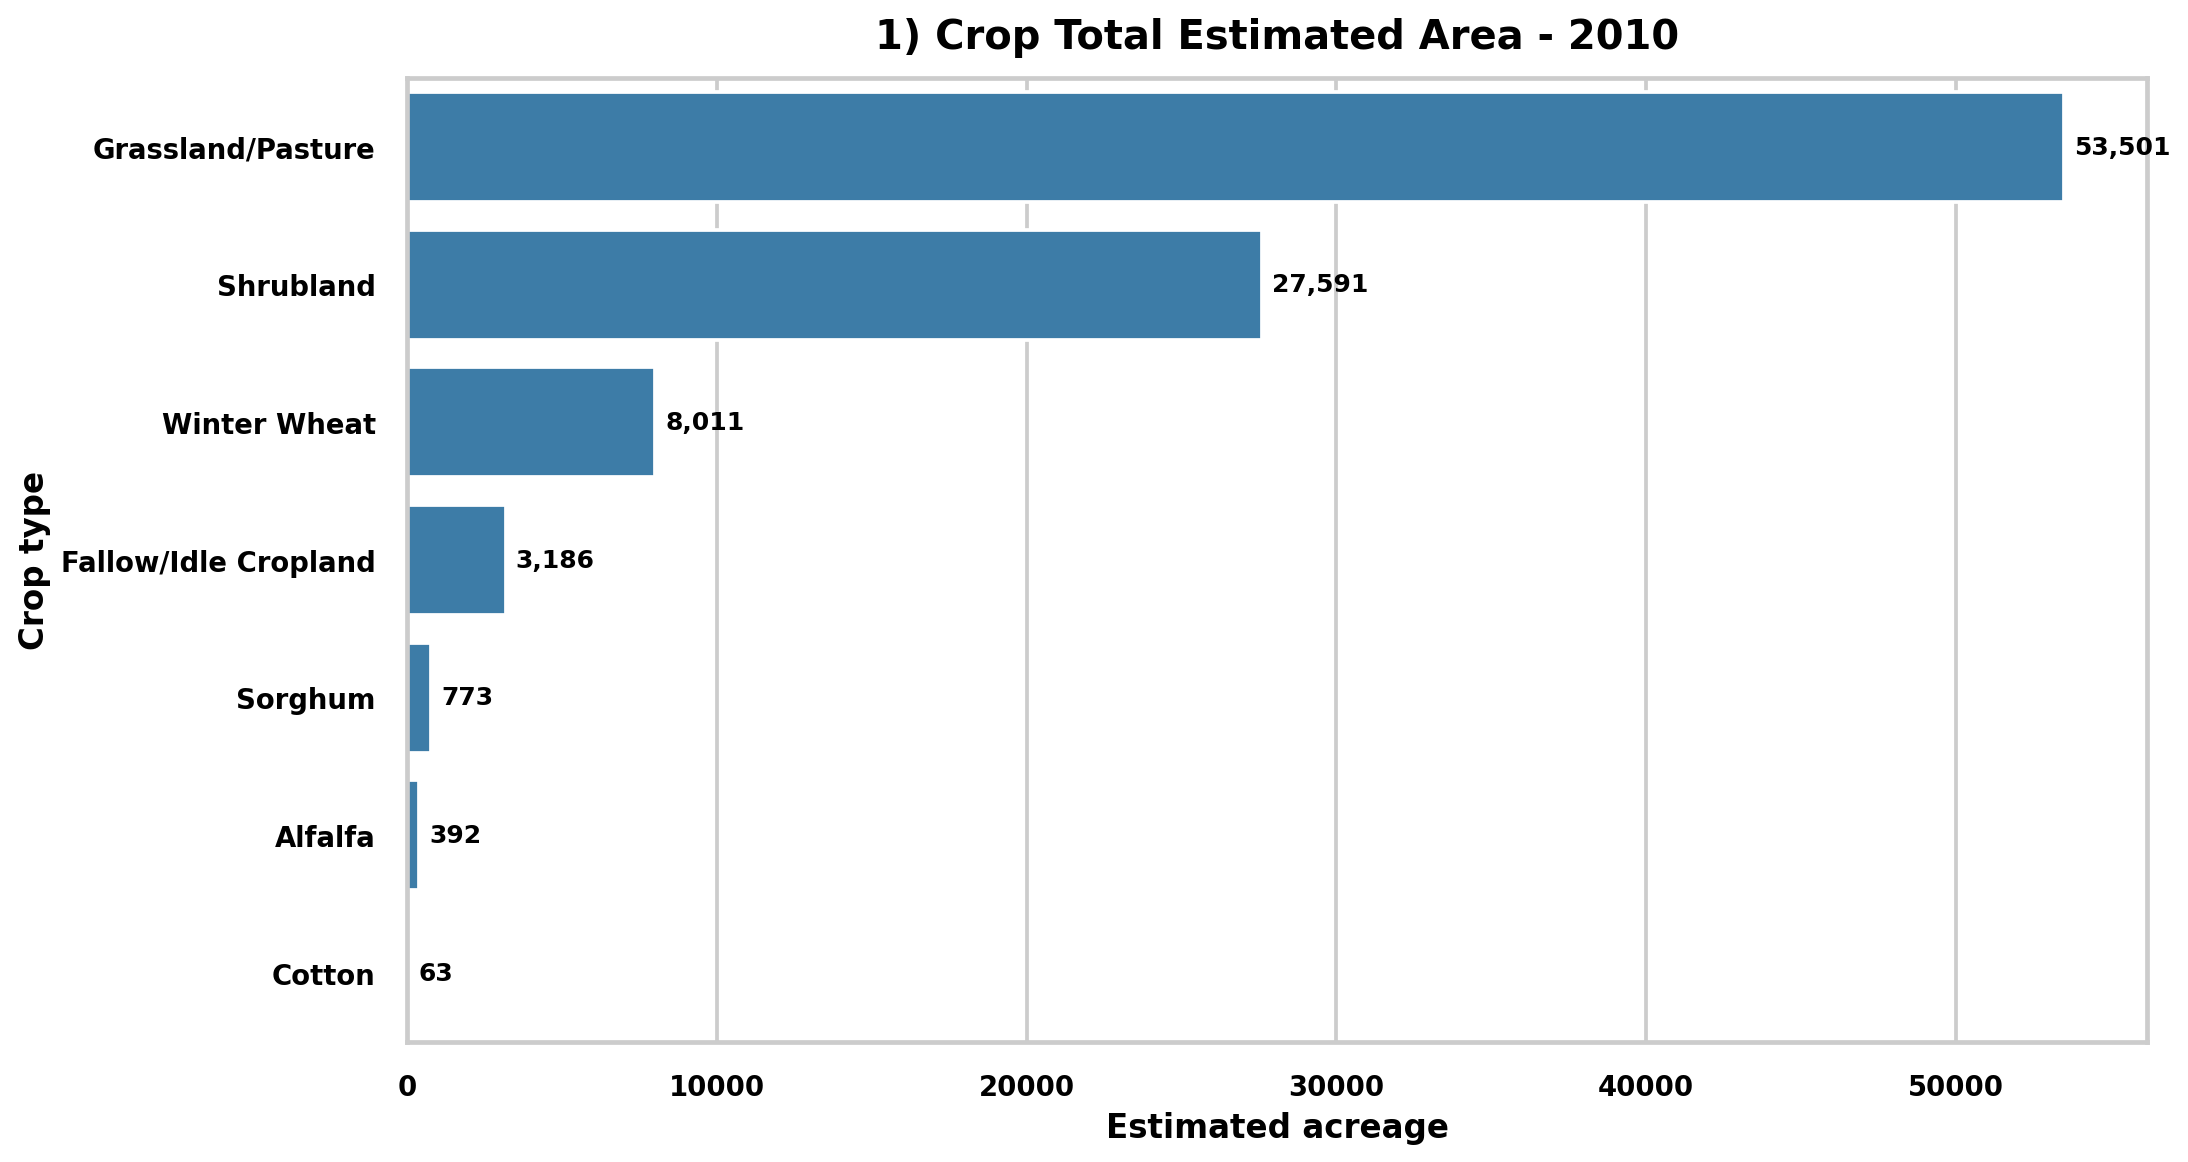

In [8]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
acreage_2010 = (
    year_df.groupby("crop_name", as_index=False)["estimated_crop_acres"]
    .sum()
    .sort_values("estimated_crop_acres", ascending=False)
)

plt.figure(figsize=(12.5, 6.8))
ax = sns.barplot(data=acreage_2010, x="estimated_crop_acres", y="crop_name", color="#2c7fb8")
style_axis(ax, "1) Crop Total Estimated Area - 2010", "Estimated acreage", "Crop type")
for container in ax.containers:
    labels = [f"{v:,.0f}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=10, padding=4, color="black", fontweight="bold")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "01_crop_total_estimated_area_2010.png", bbox_inches="tight")
plt.show()

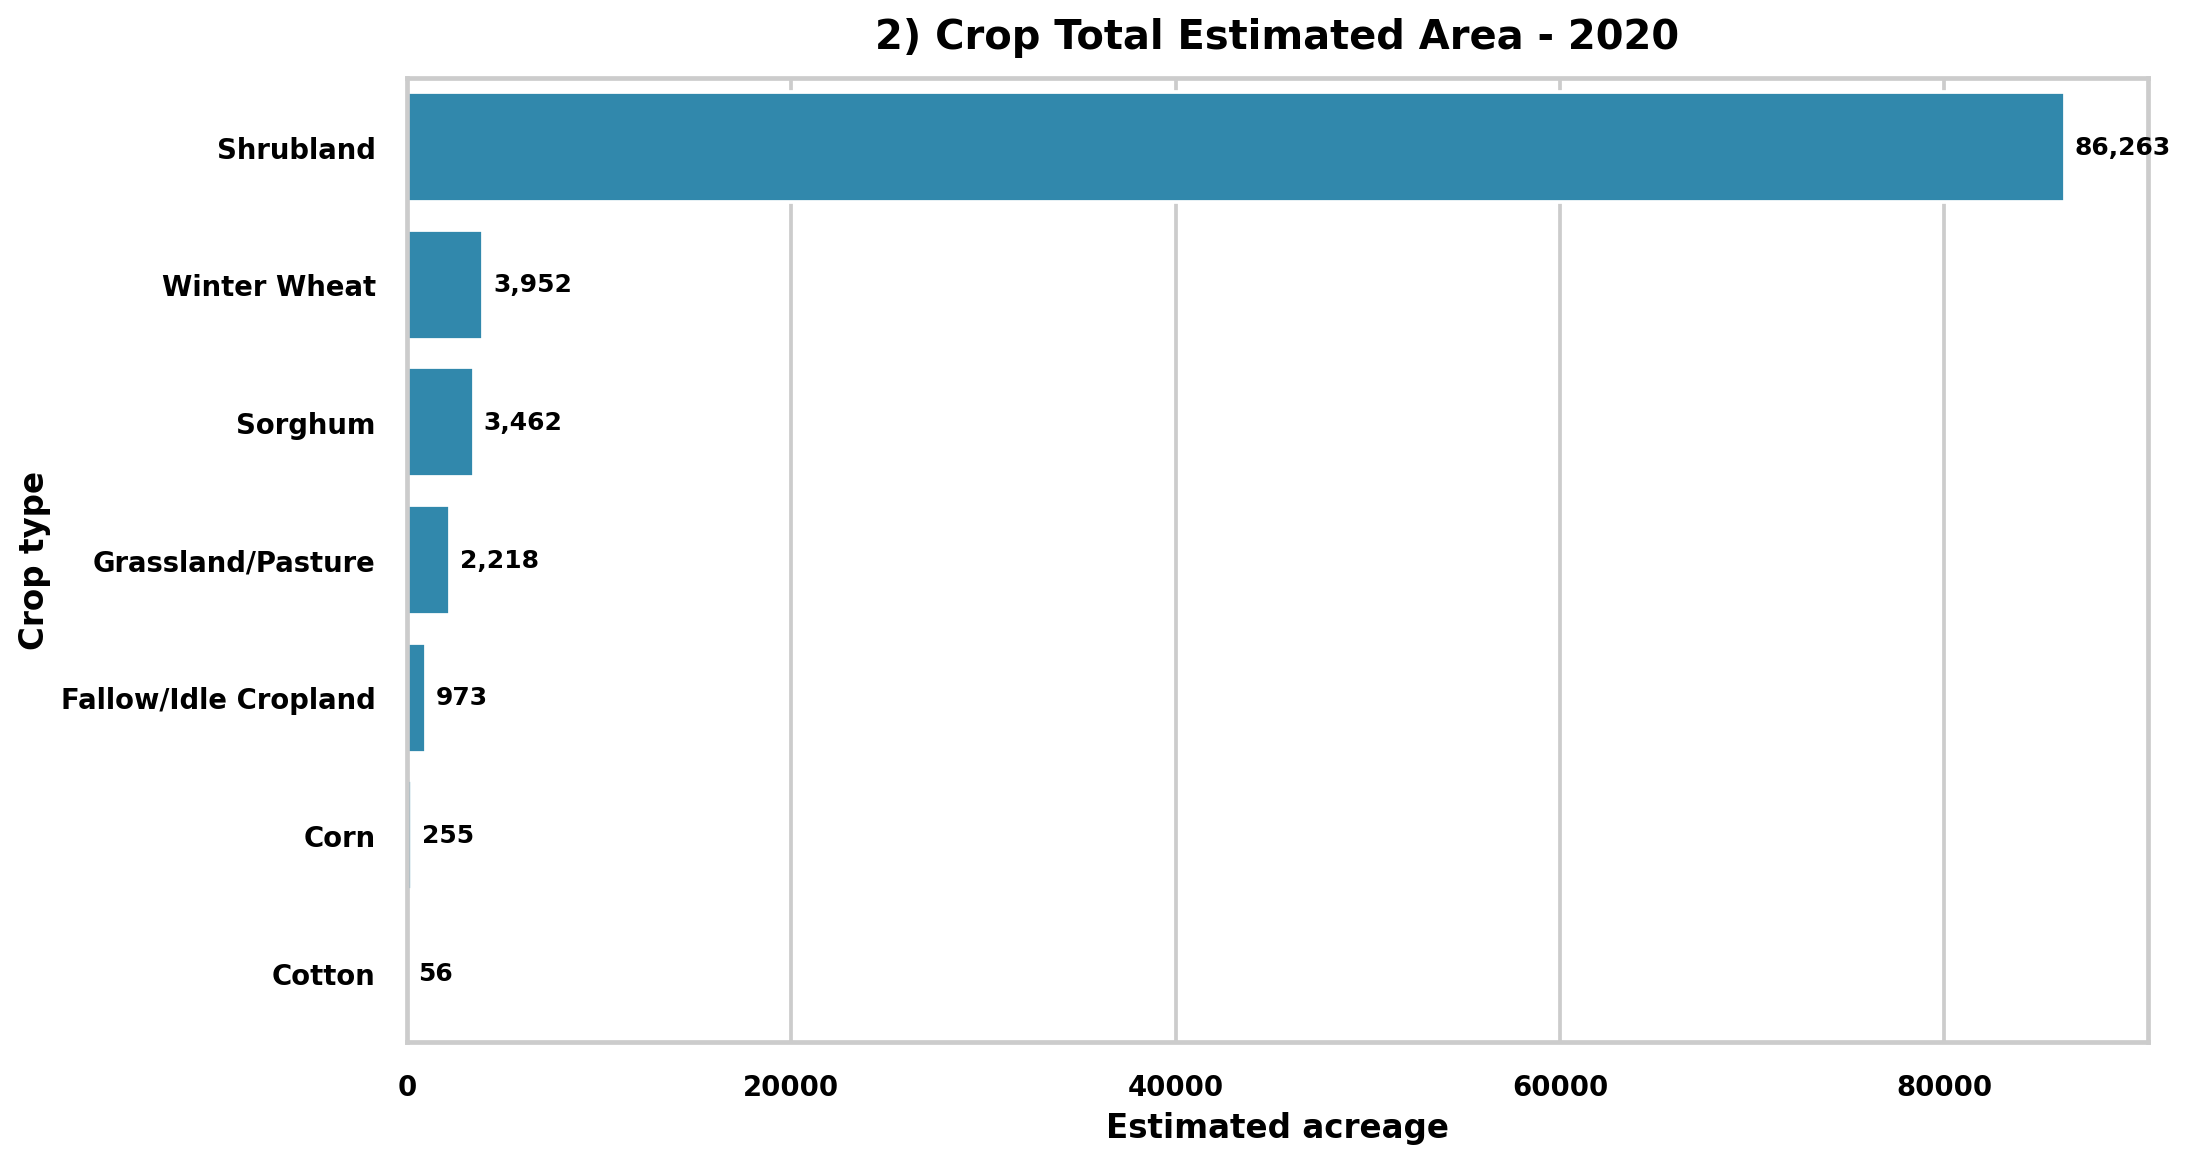

In [9]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
acreage_2020 = (
    year_df.groupby("crop_name", as_index=False)["estimated_crop_acres"]
    .sum()
    .sort_values("estimated_crop_acres", ascending=False)
)

plt.figure(figsize=(12.5, 6.8))
ax = sns.barplot(data=acreage_2020, x="estimated_crop_acres", y="crop_name", color="#1d91c0")
style_axis(ax, "2) Crop Total Estimated Area - 2020", "Estimated acreage", "Crop type")
for container in ax.containers:
    labels = [f"{v:,.0f}" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, fontsize=10, padding=4, color="black", fontweight="bold")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "02_crop_total_estimated_area_2020.png", bbox_inches="tight")
plt.show()

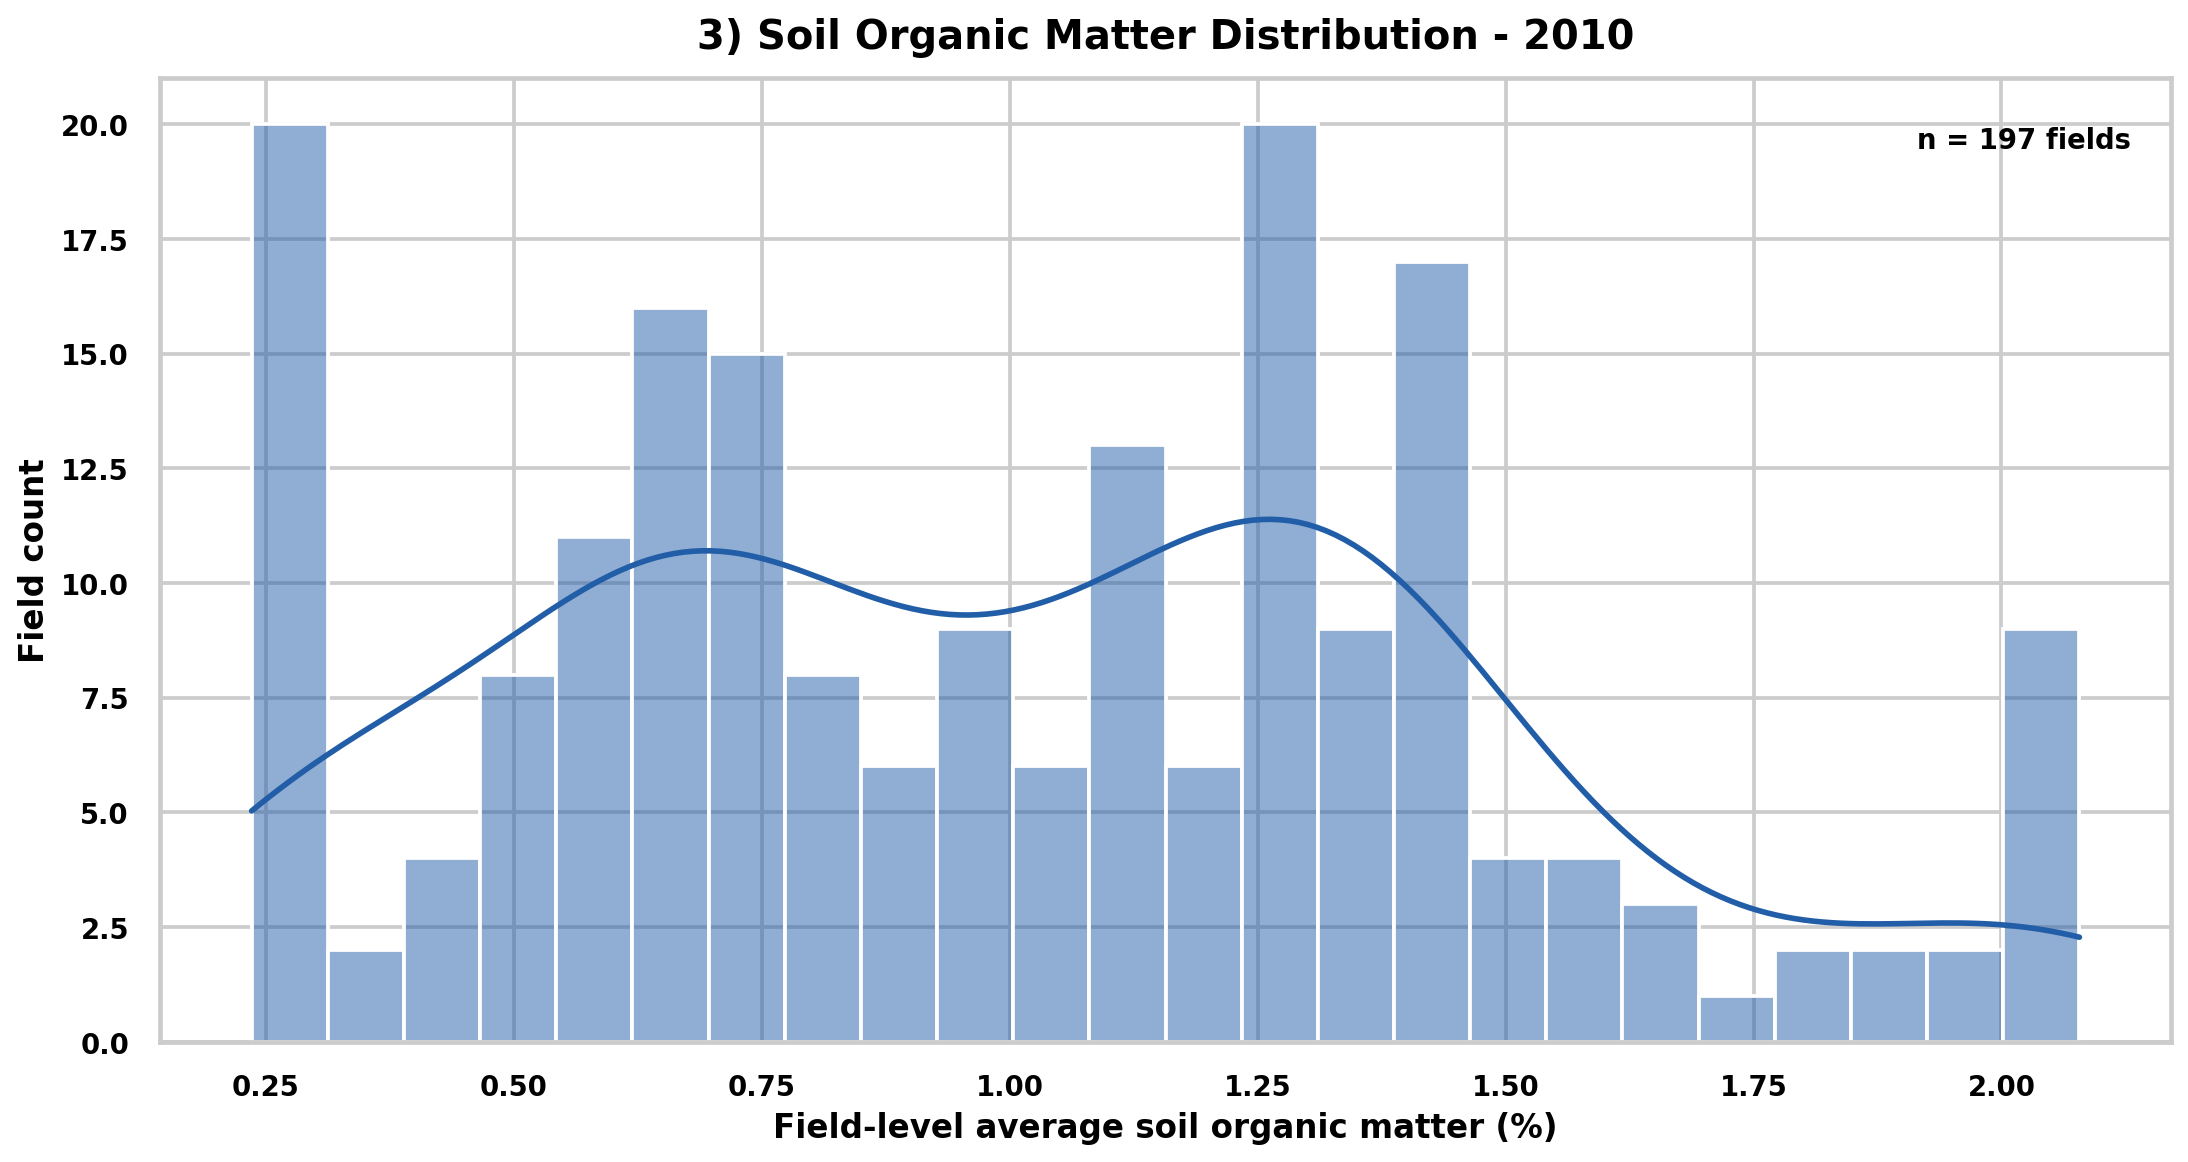

In [10]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
om_2010 = year_df[["field_id", "om_r_field_avg"]].dropna().drop_duplicates(subset=["field_id"])

plt.figure(figsize=(12.5, 6.8))
ax = sns.histplot(om_2010["om_r_field_avg"], bins=24, kde=True, color="#225ea8")
style_axis(ax, "3) Soil Organic Matter Distribution - 2010", "Field-level average soil organic matter (%)", "Field count")
ax.text(0.98, 0.95, f"n = {len(om_2010)} fields", transform=ax.transAxes, ha="right", va="top", fontsize=11, fontweight="bold", color="black")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "03_soil_organic_matter_distribution_2010.png", bbox_inches="tight")
plt.show()

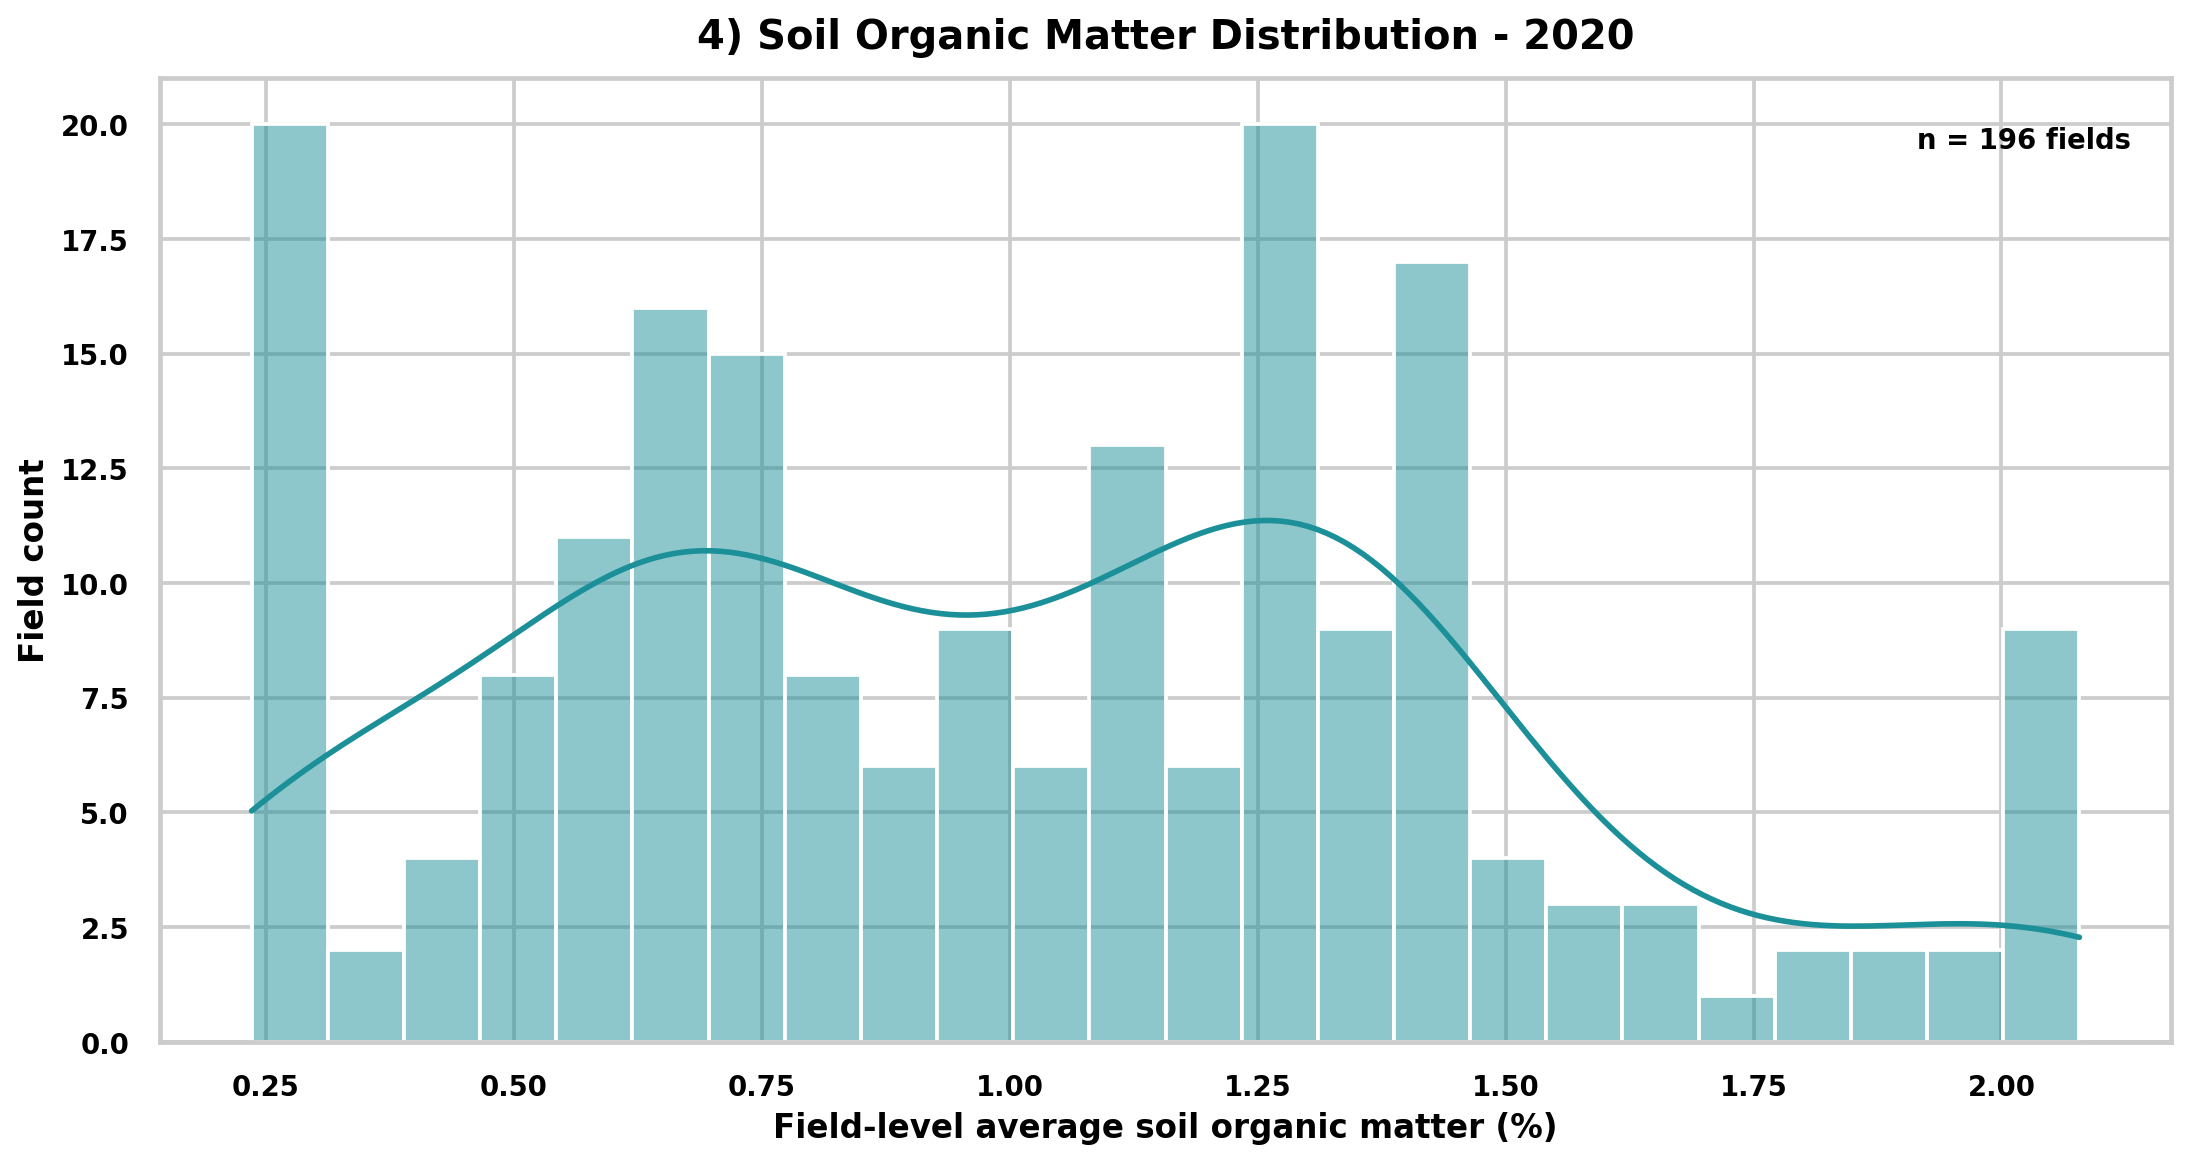

In [11]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
om_2020 = year_df[["field_id", "om_r_field_avg"]].dropna().drop_duplicates(subset=["field_id"])

plt.figure(figsize=(12.5, 6.8))
ax = sns.histplot(om_2020["om_r_field_avg"], bins=24, kde=True, color="#1c9099")
style_axis(ax, "4) Soil Organic Matter Distribution - 2020", "Field-level average soil organic matter (%)", "Field count")
ax.text(0.98, 0.95, f"n = {len(om_2020)} fields", transform=ax.transAxes, ha="right", va="top", fontsize=11, fontweight="bold", color="black")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "04_soil_organic_matter_distribution_2020.png", bbox_inches="tight")
plt.show()

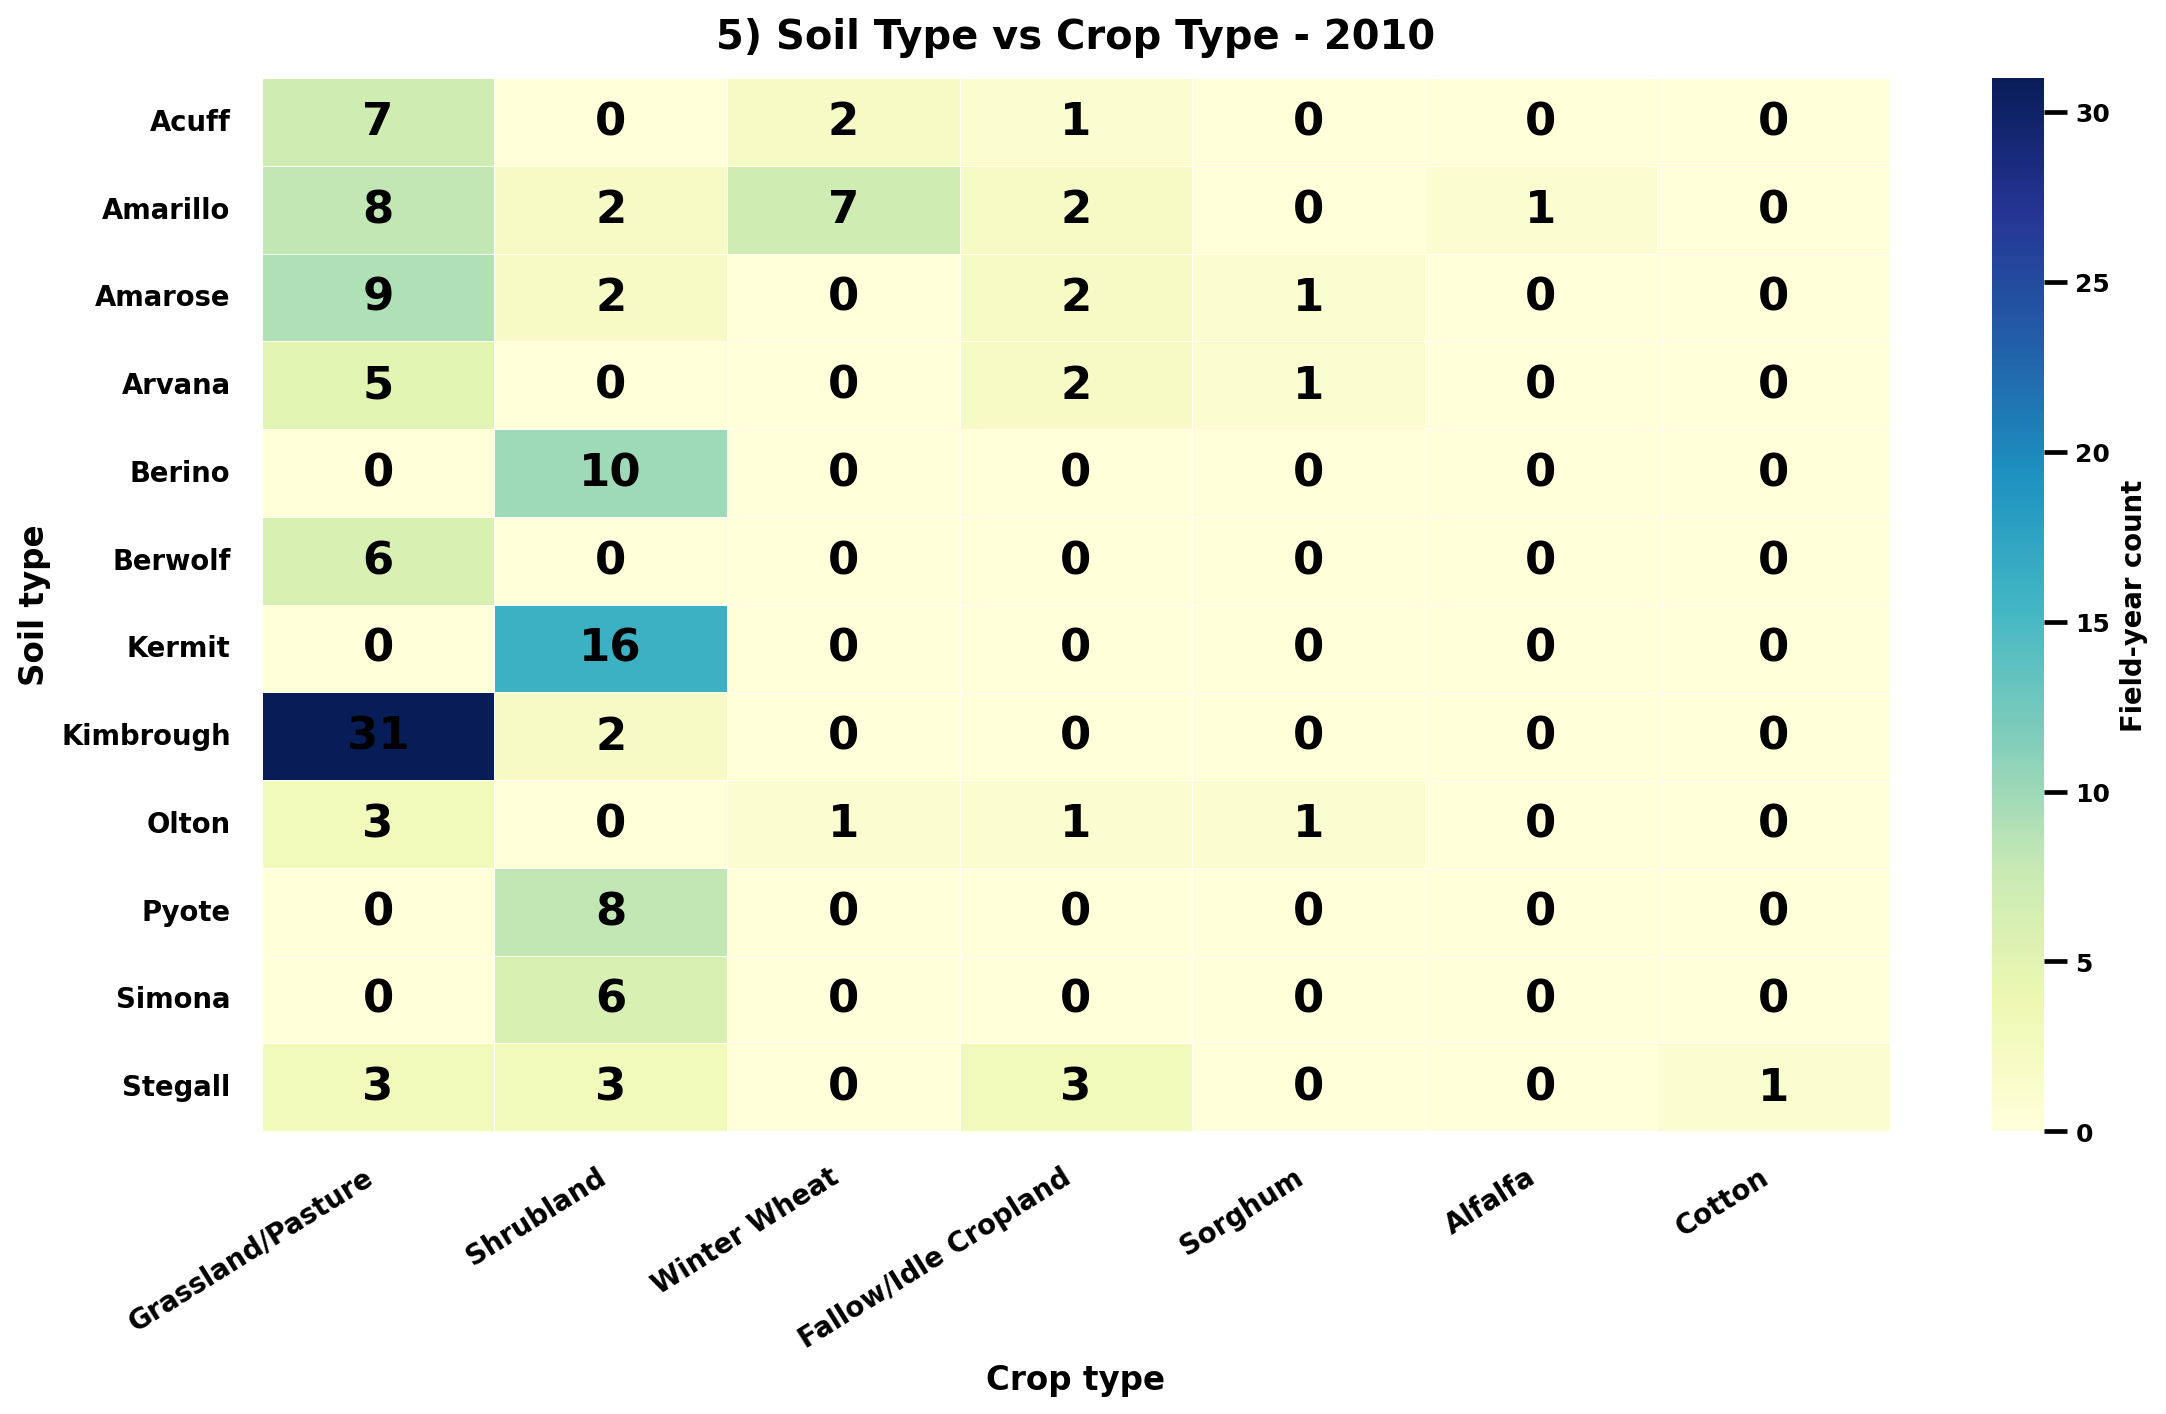

In [12]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
top_soils_2010 = year_df["soil_type"].value_counts().head(12).index
top_crops_2010 = year_df["crop_name"].value_counts().head(10).index
ct_2010 = pd.crosstab(
    year_df[year_df["soil_type"].isin(top_soils_2010)]["soil_type"],
    year_df[year_df["soil_type"].isin(top_soils_2010)]["crop_name"],
)
ct_2010 = ct_2010.reindex(columns=[c for c in top_crops_2010 if c in ct_2010.columns], fill_value=0)

plt.figure(figsize=(13.2, 8.2))
ax = sns.heatmap(ct_2010, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.35, cbar_kws={"label": "Field-year count"})
style_axis(ax, "5) Soil Type vs Crop Type - 2010", "Crop type", "Soil type")
plt.xticks(rotation=32, ha="right")
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="black", labelsize=10)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_color("black")
cbar.set_label("Field-year count", color="black", weight="bold", size=11)
for text in ax.texts:
    text.set_color("black")
    text.set_fontweight("bold")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "05_soil_type_vs_crop_type_2010.png", bbox_inches="tight")
plt.show()

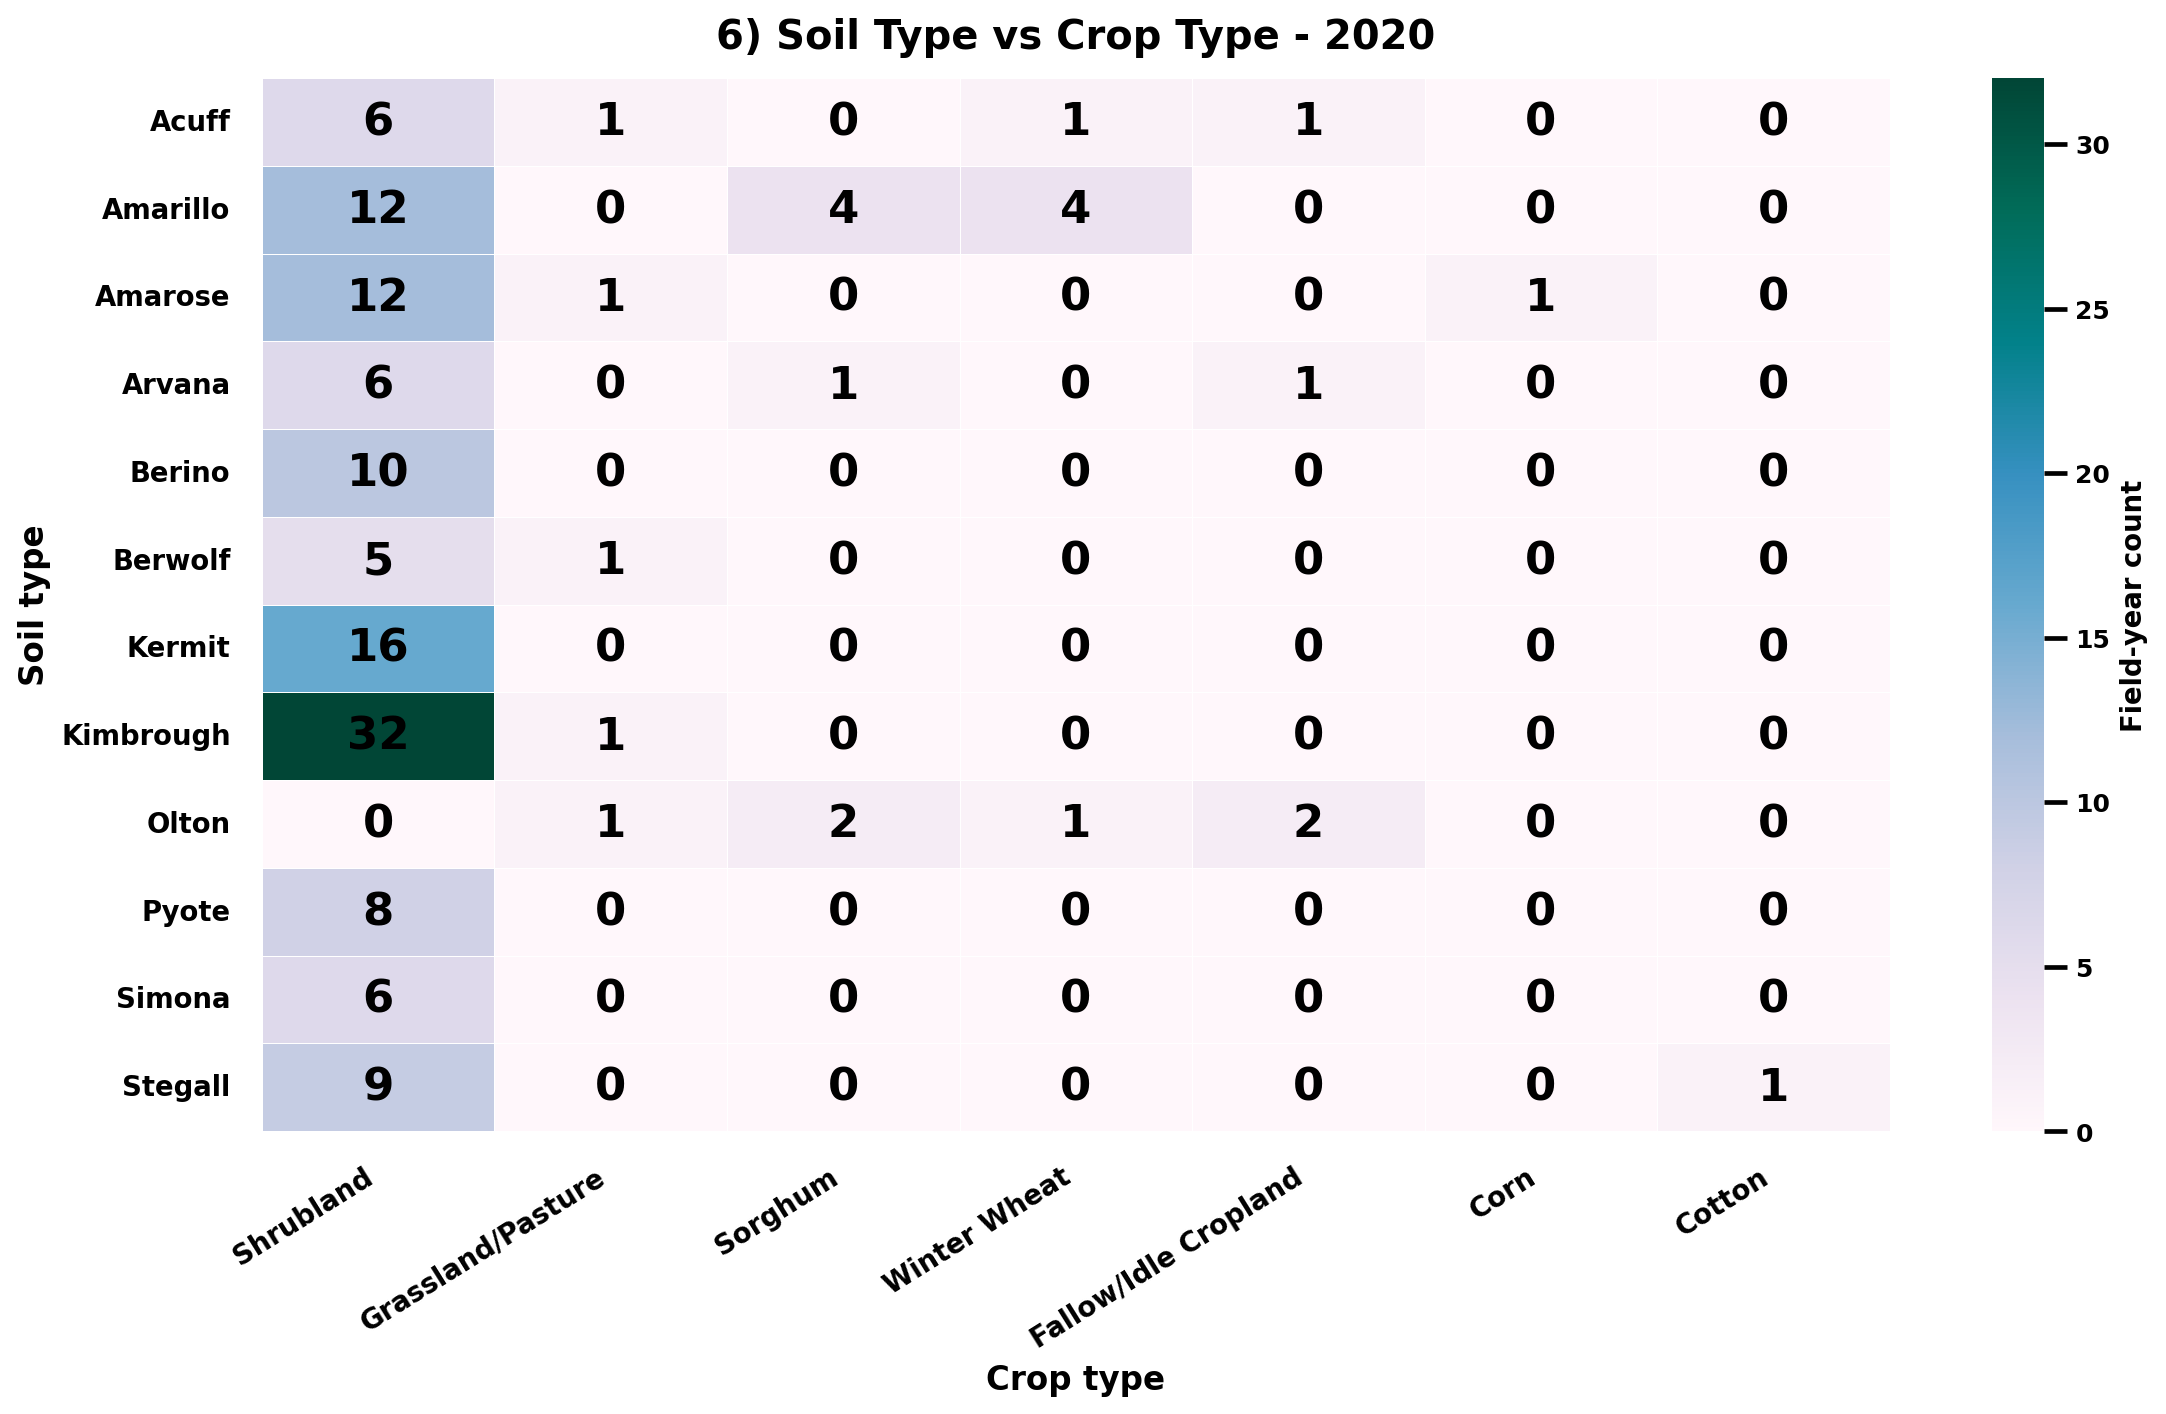

In [13]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
top_soils_2020 = year_df["soil_type"].value_counts().head(12).index
top_crops_2020 = year_df["crop_name"].value_counts().head(10).index
ct_2020 = pd.crosstab(
    year_df[year_df["soil_type"].isin(top_soils_2020)]["soil_type"],
    year_df[year_df["soil_type"].isin(top_soils_2020)]["crop_name"],
)
ct_2020 = ct_2020.reindex(columns=[c for c in top_crops_2020 if c in ct_2020.columns], fill_value=0)

plt.figure(figsize=(13.2, 8.2))
ax = sns.heatmap(ct_2020, cmap="PuBuGn", annot=True, fmt="d", linewidths=0.35, cbar_kws={"label": "Field-year count"})
style_axis(ax, "6) Soil Type vs Crop Type - 2020", "Crop type", "Soil type")
plt.xticks(rotation=32, ha="right")
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="black", labelsize=10)
for tick in cbar.ax.get_yticklabels():
    tick.set_fontweight("bold")
    tick.set_color("black")
cbar.set_label("Field-year count", color="black", weight="bold", size=11)
for text in ax.texts:
    text.set_color("black")
    text.set_fontweight("bold")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "06_soil_type_vs_crop_type_2020.png", bbox_inches="tight")
plt.show()

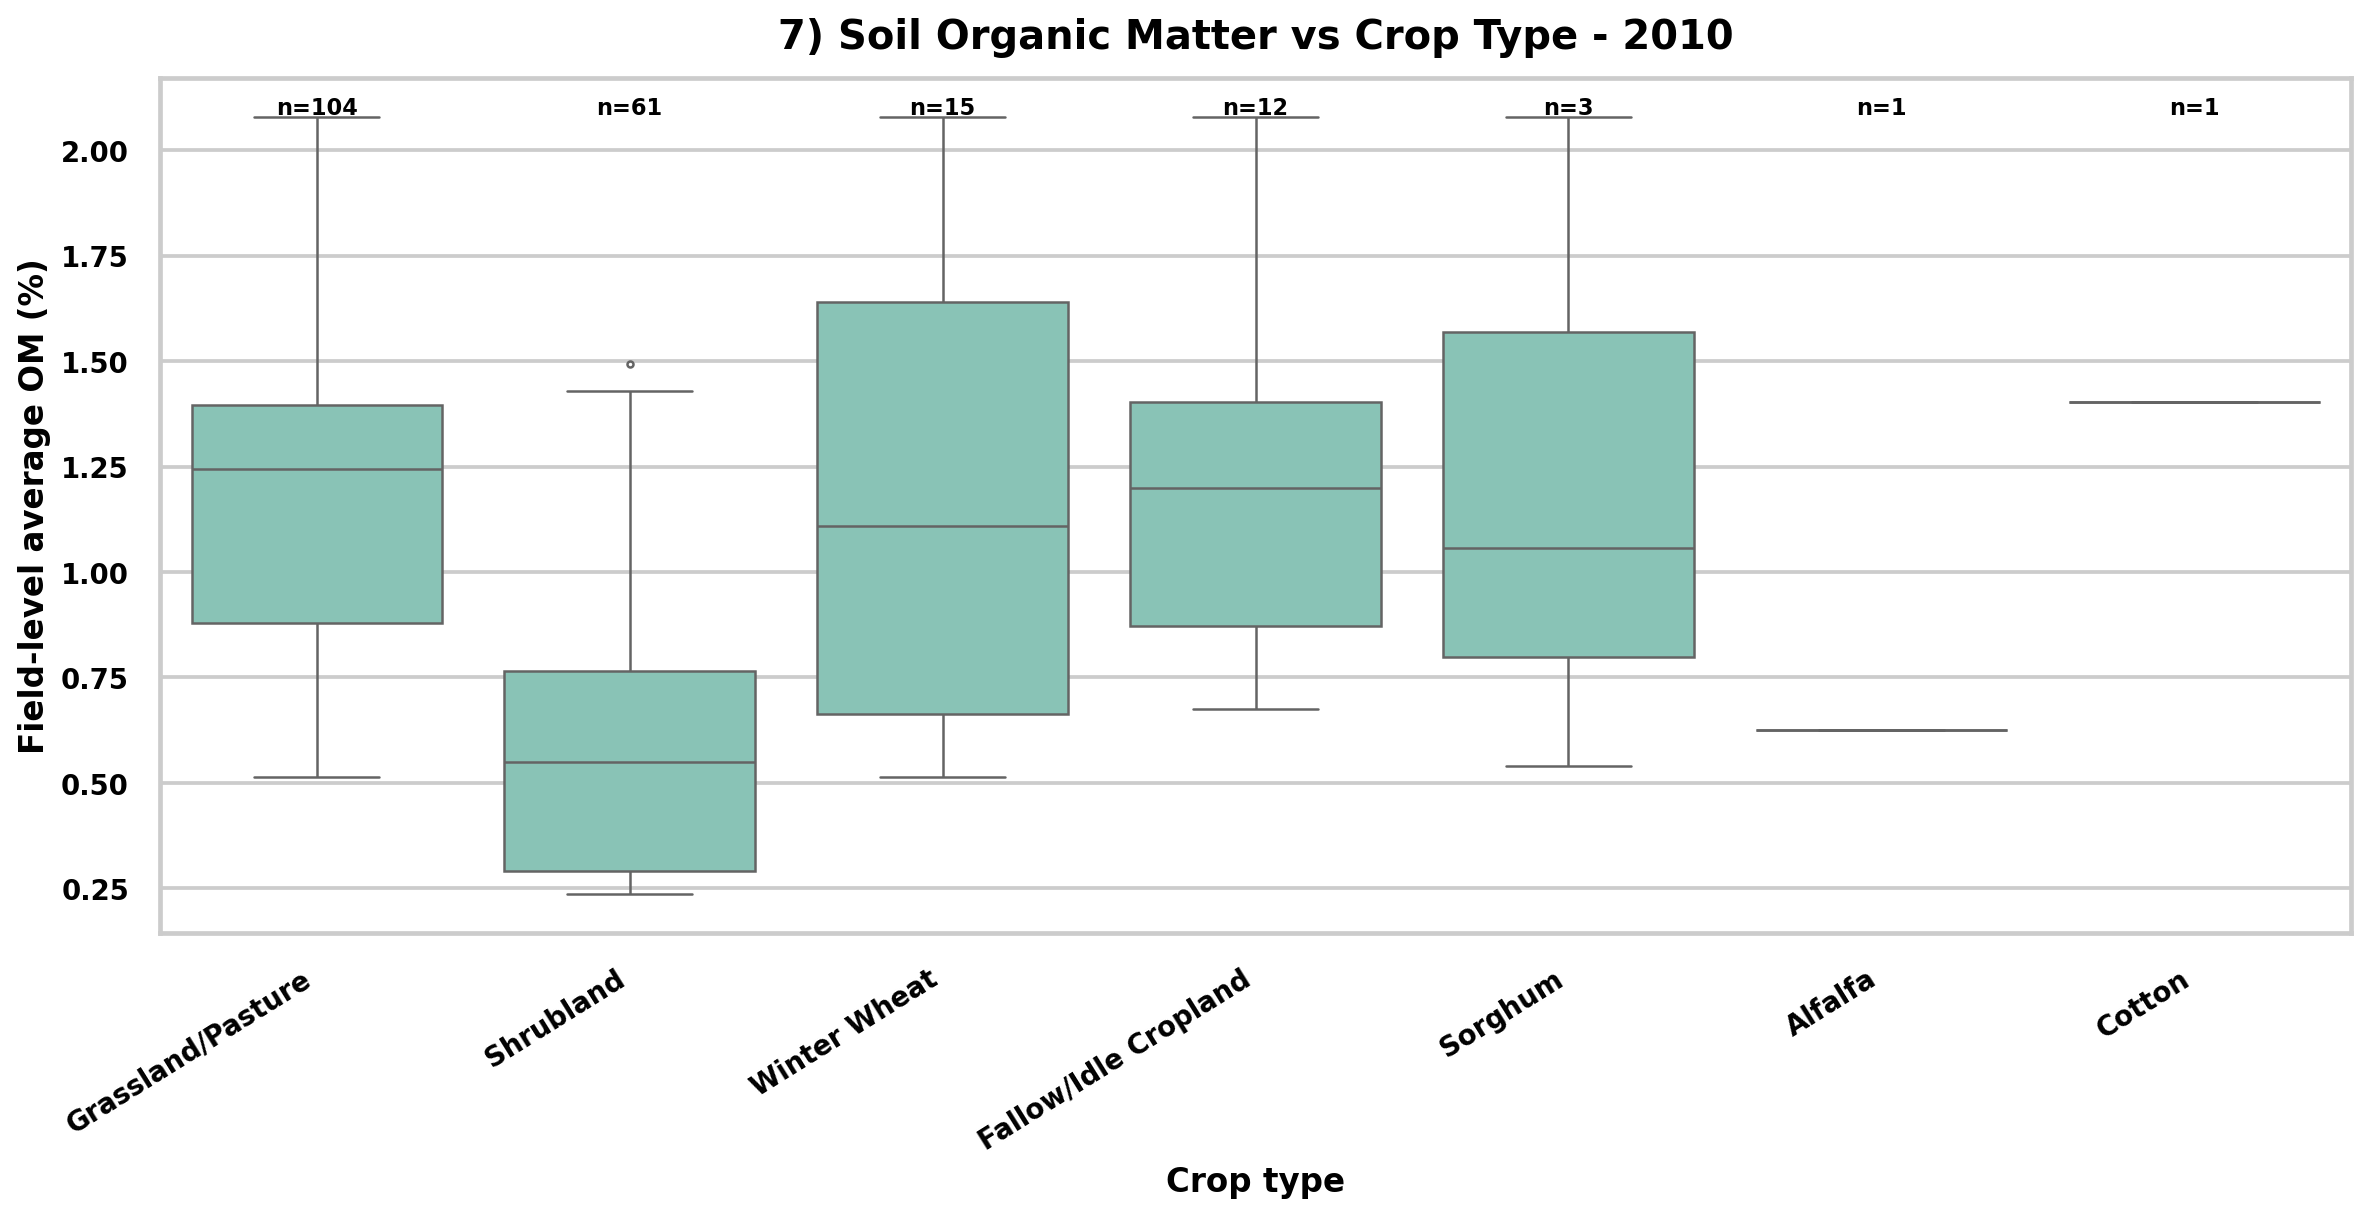

In [14]:
year_df = dashboard_df[dashboard_df["year"] == 2010].copy()
top_crops_2010 = year_df["crop_name"].value_counts().head(10).index
om_crop_2010 = year_df[year_df["crop_name"].isin(top_crops_2010)].copy()
crop_order_2010 = om_crop_2010["crop_name"].value_counts().index.tolist()

plt.figure(figsize=(13.5, 7.1))
ax = sns.boxplot(
    data=om_crop_2010,
    x="crop_name",
    y="om_r_field_avg",
    order=crop_order_2010,
    color="#7fcdbb",
    fliersize=2.4,
)
style_axis(ax, "7) Soil Organic Matter vs Crop Type - 2010", "Crop type", "Field-level average OM (%)")
plt.xticks(rotation=32, ha="right")
for i, crop in enumerate(crop_order_2010):
    n_val = int((om_crop_2010["crop_name"] == crop).sum())
    ax.text(i, ax.get_ylim()[1] * 0.98, f"n={n_val}", ha="center", va="top", fontsize=9, fontweight="bold", color="black")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "07_soil_organic_matter_vs_crop_type_2010.png", bbox_inches="tight")
plt.show()

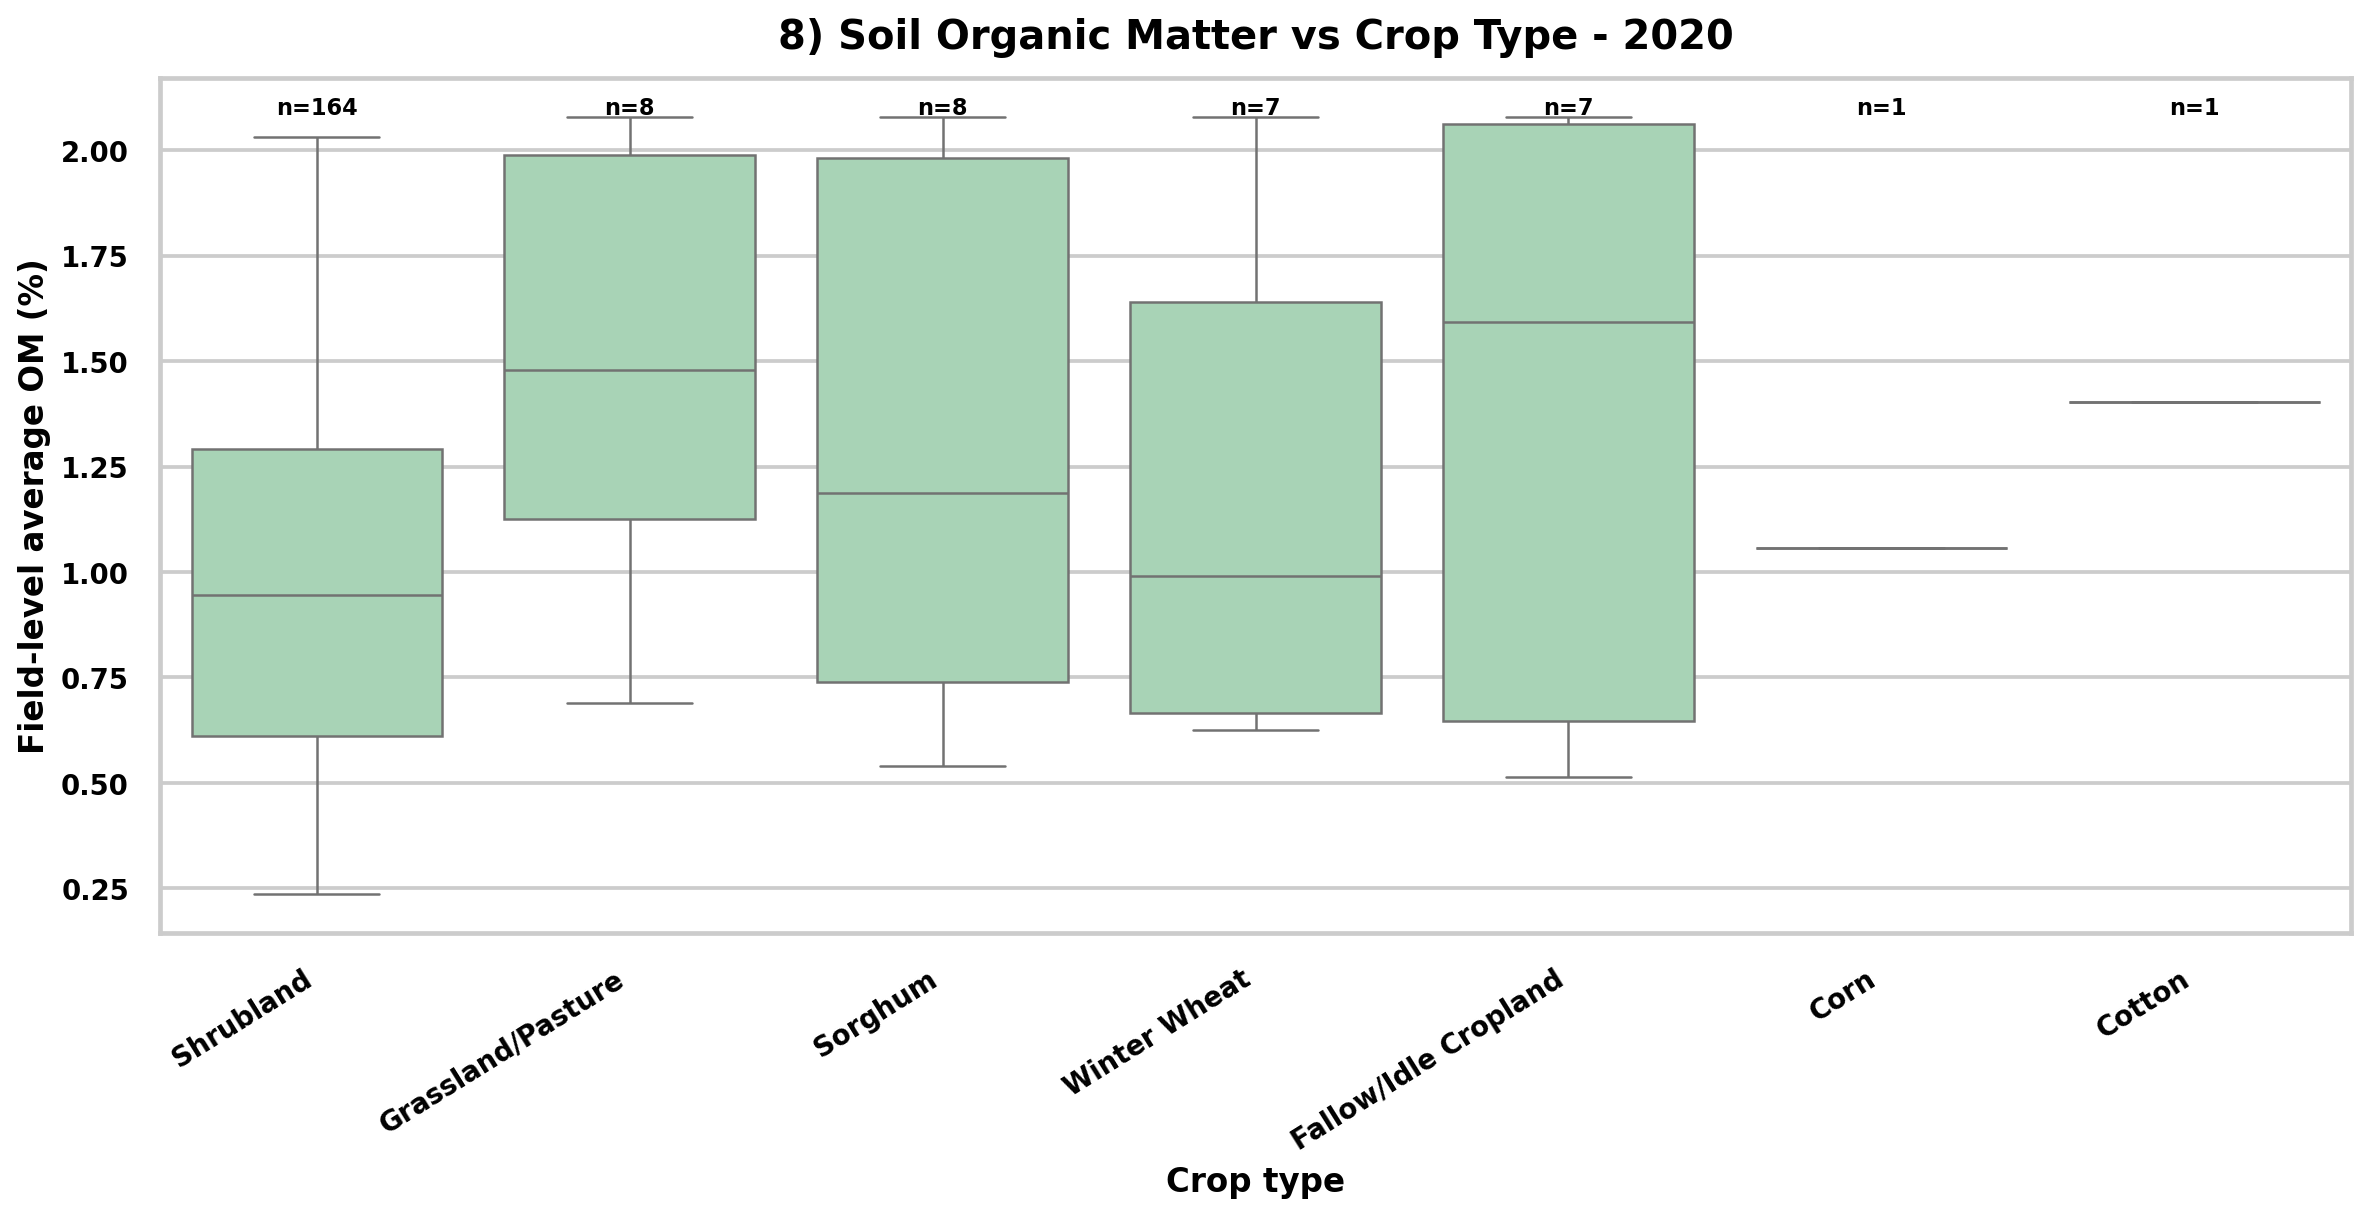

In [15]:
year_df = dashboard_df[dashboard_df["year"] == 2020].copy()
top_crops_2020 = year_df["crop_name"].value_counts().head(10).index
om_crop_2020 = year_df[year_df["crop_name"].isin(top_crops_2020)].copy()
crop_order_2020 = om_crop_2020["crop_name"].value_counts().index.tolist()

plt.figure(figsize=(13.5, 7.1))
ax = sns.boxplot(
    data=om_crop_2020,
    x="crop_name",
    y="om_r_field_avg",
    order=crop_order_2020,
    color="#a1dab4",
    fliersize=2.4,
)
style_axis(ax, "8) Soil Organic Matter vs Crop Type - 2020", "Crop type", "Field-level average OM (%)")
plt.xticks(rotation=32, ha="right")
for i, crop in enumerate(crop_order_2020):
    n_val = int((om_crop_2020["crop_name"] == crop).sum())
    ax.text(i, ax.get_ylim()[1] * 0.98, f"n={n_val}", ha="center", va="top", fontsize=9, fontweight="bold", color="black")
plt.tight_layout()
plt.savefig(DASHBOARD_ASSETS_DIR / "08_soil_organic_matter_vs_crop_type_2020.png", bbox_inches="tight")
plt.show()

In [16]:
pairs = [
    {
        "metric": "Crop Total Estimated Area",
        "img_2010": "01_crop_total_estimated_area_2010.png",
        "img_2020": "02_crop_total_estimated_area_2020.png",
        "desc": "Estimated acreage by crop class after exclusion filtering.",
    },
    {
        "metric": "Soil Organic Matter Distribution",
        "img_2010": "03_soil_organic_matter_distribution_2010.png",
        "img_2020": "04_soil_organic_matter_distribution_2020.png",
        "desc": "Field-level OM distributions with counts for each year.",
    },
    {
        "metric": "Soil Type vs Crop Type",
        "img_2010": "05_soil_type_vs_crop_type_2010.png",
        "img_2020": "06_soil_type_vs_crop_type_2020.png",
        "desc": "Count heatmaps of soil-crop combinations by year.",
    },
    {
        "metric": "Soil Organic Matter vs Crop Type",
        "img_2010": "07_soil_organic_matter_vs_crop_type_2010.png",
        "img_2020": "08_soil_organic_matter_vs_crop_type_2020.png",
        "desc": "OM boxplots by crop class with sample-size labels.",
    },
]

row_html = ""
for pair in pairs:
    row_html += f"""
    <section class='row-block'>
      <div class='row-head'>
        <h2>{pair['metric']}</h2>
        <p>{pair['desc']}</p>
      </div>
      <div class='two-col'>
        <article class='card'>
          <h3>2010</h3>
          <img class='clickable-plot' src='dashboard_assets/{pair['img_2010']}' alt='{pair['metric']} - 2010' loading='lazy' />
        </article>
        <article class='card'>
          <h3>2020</h3>
          <img class='clickable-plot' src='dashboard_assets/{pair['img_2020']}' alt='{pair['metric']} - 2020' loading='lazy' />
        </article>
      </div>
    </section>
    """

trend_text = (
    "Across both years, acreage and soil-crop combinations remain concentrated in a few dominant classes while minor classes contribute much less coverage. "
    "The OM charts suggest broadly similar central tendency between 2010 and 2020, with differences appearing mainly in category-level spread and sample composition."
)

dashboard_html = f"""<!doctype html>
<html lang='en'>
<head>
  <meta charset='utf-8' />
  <meta name='viewport' content='width=device-width, initial-scale=1' />
  <title>Assignment 03 EDA Dashboard</title>
  <style>
    :root {{
      --bg: #f4f6f8;
      --panel: #ffffff;
      --ink: #0f1720;
      --line: #d9dee5;
      --muted: #4b5563;
      --accent: #0a5a7c;
    }}
    * {{ box-sizing: border-box; }}
    body {{ margin: 0; background: var(--bg); color: var(--ink); font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; }}
    .wrap {{ max-width: 1500px; margin: 0 auto; padding: 26px 18px 42px; }}
    header {{ background: linear-gradient(145deg, #0e3850, #24748f); color: #fff; border-radius: 14px; padding: 22px; margin-bottom: 14px; }}
    header h1 {{ margin: 0 0 7px 0; font-size: 1.9rem; }}
    header p {{ margin: 4px 0; line-height: 1.4; max-width: 1080px; }}
    .trend {{ background: #ffffff; border: 1px solid var(--line); border-left: 6px solid var(--accent); border-radius: 10px; padding: 12px 14px; margin-bottom: 16px; }}
    .trend h2 {{ margin: 0 0 6px 0; font-size: 1.05rem; color: #111827; }}
    .trend p {{ margin: 0; color: #1f2937; line-height: 1.45; }}
    .row-block {{ margin-bottom: 18px; }}
    .row-head {{ margin-bottom: 8px; }}
    .row-head h2 {{ margin: 0 0 4px 0; font-size: 1.1rem; }}
    .row-head p {{ margin: 0; color: var(--muted); font-size: 0.94rem; }}
    .two-col {{ display: grid; grid-template-columns: 1fr 1fr; gap: 14px; }}
    .card {{ background: var(--panel); border: 1px solid var(--line); border-radius: 12px; padding: 12px; box-shadow: 0 1px 4px rgba(0, 0, 0, 0.05); }}
    .card h3 {{ margin: 0 0 8px 0; font-size: 1rem; color: #0f1720; }}
    .card img {{ width: 100%; border: 1px solid var(--line); border-radius: 8px; cursor: zoom-in; background: #fff; }}
    .modal {{ position: fixed; inset: 0; background: rgba(9, 12, 16, 0.82); display: none; align-items: center; justify-content: center; padding: 20px; z-index: 9999; }}
    .modal.open {{ display: flex; }}
    .modal-inner {{ max-width: min(96vw, 1800px); max-height: 92vh; position: relative; }}
    .modal-inner img {{ max-width: 100%; max-height: 92vh; border-radius: 10px; border: 2px solid #fff; background: #fff; }}
    .modal-close {{ position: absolute; right: -6px; top: -42px; color: #fff; border: 1px solid rgba(255,255,255,0.6); border-radius: 8px; background: rgba(0,0,0,0.35); padding: 6px 10px; cursor: pointer; font-size: 1rem; }}
    footer {{ margin-top: 18px; color: var(--muted); font-size: 0.88rem; }}
    @media (max-width: 980px) {{ .two-col {{ grid-template-columns: 1fr; }} }}
  </style>
</head>
<body>
  <div class='wrap'>
    <header>
      <h1>Assignment 03 - Field EDA Dashboard</h1>
      <p>Side-by-side comparison of 2010 and 2020 agronomic patterns using consistent filtering and chart design.</p>
      <p>Excluded categories: Other Hay/Non Alfalfa, Code_236, Developed/Medium Intensity, Developed/Low Intensity, and Open Water.</p>
    </header>
    <section class='trend'>
      <h2>Trend Snapshot</h2>
      <p>{trend_text}</p>
    </section>
    <main>{row_html}</main>
    <footer>Tip: click any chart to expand it in a pop-up view.</footer>
  </div>
  <div id='plot-modal' class='modal' aria-hidden='true'>
    <div class='modal-inner'>
      <button id='modal-close' class='modal-close' type='button'>Close ✕</button>
      <img id='modal-image' src='' alt='Expanded chart view' />
    </div>
  </div>
  <script>
    (function () {{
      const modal = document.getElementById('plot-modal');
      const modalImage = document.getElementById('modal-image');
      const closeBtn = document.getElementById('modal-close');
      const images = document.querySelectorAll('.clickable-plot');

      function openModal(src, alt) {{
        modalImage.src = src;
        modalImage.alt = alt || 'Expanded chart';
        modal.classList.add('open');
        modal.setAttribute('aria-hidden', 'false');
      }}

      function closeModal() {{
        modal.classList.remove('open');
        modal.setAttribute('aria-hidden', 'true');
        modalImage.src = '';
      }}

      images.forEach((img) => {{
        img.addEventListener('click', () => openModal(img.getAttribute('src'), img.getAttribute('alt')));
      }});

      closeBtn.addEventListener('click', closeModal);
      modal.addEventListener('click', (event) => {{
        if (event.target === modal) closeModal();
      }});
      document.addEventListener('keydown', (event) => {{
        if (event.key === 'Escape' && modal.classList.contains('open')) closeModal();
      }});
    }})();
  </script>
</body>
</html>
"""

dashboard_path = OUTPUT_DIR / "field_eda_dashboard.html"
dashboard_path.write_text(dashboard_html, encoding="utf-8")
print(f"Dashboard written: {dashboard_path}")

Dashboard written: /workspaces/EVTLR-Project/output/field_eda_dashboard.html


### Interpretation

The year-paired layout makes it easier to compare changes directly across the same metric. For each row, focus on rank shifts, spread changes, and whether dominant classes remain stable between 2010 and 2020.